<p style='text-align: center;'>

## <p style='text-align: center;'> **This is the Notebook for the CIFO Project**

### <p style='text-align: center;'> **Group: C37 Vestigial**




In [1]:
# Numerical arrays and vectorized operations used for triangle genomes and RMSE calculations.
import numpy as np

# Plotting library used to show final images and convergence curves inside the notebook.
import matplotlib.pyplot as plt

# Random utilities used by the genetic algorithm: initialization, selection, and mutation.
from random import randint, choices, sample, random

# OpenCV is used to load images, draw filled triangles, and save generated outputs.
import cv2

# ABC/abstractmethod are used to define a generic optimization solution template.
from abc import ABC, abstractmethod

# deepcopy prevents offspring/elites from accidentally sharing the same object in memory as parents.
from copy import deepcopy

In [2]:
class Solution(ABC):
    """Generic abstract class for an optimization solution."""

    def __init__(self, repr=None):
        # If no representation is provided, create a random one using the subclass method.
        if repr is None:
            repr = self.random_initial_representation()

        # Store the representation/genome of the solution.
        self.repr = repr

    def __repr__(self):
        # Defines how the solution is displayed when printed.
        return str(self.repr)

    @abstractmethod
    def fitness(self):
        # Every specific solution must define how quality/fitness is calculated.
        pass

    @abstractmethod
    def random_initial_representation(self):
        # Every specific solution must define how a random starting solution is created.
        pass

In [4]:
class VermeerSolution(Solution):
    """A candidate painting made from 100 colored triangles."""

    def __init__(self, target_image, repr=None):
        # Store the original image that the generated triangle image will be compared against.
        self.target_image = target_image

        # Project canvas size: 300x400 pixels.
        self.width = 300
        self.height = 400

        # Project requirement: use 100 triangles.
        self.num_triangles = 100

        # Calls Solution.__init__, which either stores a provided repr or creates a random one.
        super().__init__(repr=repr)

    def random_initial_representation(self):
        """
        Generates a random genome of 100 small triangles.
        Each row has: [x1, y1, x2, y2, x3, y3, r, g, b]
        """

        # Matrix with one row per triangle and 9 values per triangle.
        random_repr = np.zeros((self.num_triangles, 9), dtype=int)

        for i in range(self.num_triangles):
            # Pick a random center points in the canvas for the triangle
            cx = randint(0, self.width)
            cy = randint(0, self.height)

            # Define an max radius for the triangles
            radius = 40
            # Generate 3 random x-coordinates and 3 random y-coordinates within the range of the defined radius
            # This allows to control the size of the randomly intialized traingles (can start with small triangles)
            x1 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y1 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x2 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y2 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x3 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y3 = np.clip(cy + randint(-radius, radius), 0, self.height)
            # Generate one random RGB color for the whole triangle.
            r, g, b = [randint(0, 255) for _ in range(3)]
            # Store the triangle's vertices and color in the genome.
            random_repr[i] = [x1, y1, x2, y2, x3, y3, r, g, b]

        return random_repr

    def render_canvas(self):
        """Converts the 100-triangle genome into an actual image matrix."""

        # Start from a black image with shape: height x width x RGB channels.
        canvas = np.zeros((self.height, self.width, 3), dtype=np.uint8)

        for gene in self.repr:
            # Extract the three triangle vertices in OpenCV's expected format.
            pts = np.array(
                [[gene[0], gene[1]], [gene[2], gene[3]], [gene[4], gene[5]]], np.int32
            )

            # Reshape points so cv2.fillPoly can draw the triangle.
            pts = pts.reshape((-1, 1, 2))

            # Extract the triangle color.
            # NOTE: The loaded OpenCV image is BGR, but the project logic treats these as channel values consistently.
            color = (int(gene[6]), int(gene[7]), int(gene[8]))

            # Draw a filled triangle on the canvas.
            cv2.fillPoly(canvas, [pts], color)

        return canvas

    def fitness(self):
        """Calculates RMSE between the target image and the generated triangle image.
        Applies a small penalty to overlapping triangles in order to try and resolve the problem with facial features
        """

        # Render this individual's genome into an image.
        generated_image = self.render_canvas()

        # Convert to float before subtracting, avoiding uint8 overflow/underflow errors.
        target_float = self.target_image.astype(np.float32)
        gen_float = generated_image.astype(np.float32)

        # Pixel-by-pixel difference between target and generated image.
        diff = target_float - gen_float
        # RMSE = sqrt(mean(square(error))). Lower RMSE means a better image.
        sq_diff = np.square(diff)
        mse = np.mean(sq_diff)
        rmse = np.sqrt(mse)

        # The final fitness is the visual error PLUS the geometric penalty
        return rmse

In [5]:
# Path to João's local copy of the target image.
joao_path = r"C:\Users\joaoa\Desktop\CIFO\data\girl_pearl_earing.png"
goncalo_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"
rafa_path = r"..\Project\girl_pearl_earing.png"
gui_path = r"C:\Users\User\Desktop\semestre_2\Inteligencia_Computacional_Otimizacao\CIFO_Group37_Vestigial\Project\girl_pearl_earing.png"
# Load the original image using OpenCV.
original_image = cv2.imread(rafa_path)

# Fail early with a clear error if the path is wrong or the image cannot be read.
if original_image is None:
    raise FileNotFoundError(f"OpenCV could not find the image at: {rafa_path}")

# Create one random triangle painting to test the VermeerSolution class.
first_painting = VermeerSolution(
    target_image=original_image
)

# Print its genome and RMSE fitness to confirm the representation and fitness function work.
print(f"{first_painting.repr} has fitness {first_painting.fitness()}")

[[101  69 149  60  90  60  68 254  94]
 [133 153 187 163 198 194 230  51  36]
 [276   0 295   0 249  39 217 168  81]
 [211  93 188  33 193  72 232  69 182]
 [155 258 221 243 168 273 236 145 182]
 [280 400 299 400 300 400 109 159 245]
 [257 288 221 342 229 306 157 218  25]
 [ 91 185  83 205  13 160 232 103 240]
 [300 184 237 154 242 162  25 142 239]
 [290  48 260  96 251  83 247 171 243]
 [159 277 123 246 147 299  35   4 183]
 [ 74 271  38 263  26 292  79 103 194]
 [ 89 177 153 186 119 164 171  39 130]
 [112 185 110 166  59 148  18 168  94]
 [ 41 254 103 297  48 281  38 203  62]
 [  0   6  40   0   0  12  83 216 203]
 [230   0 223   0 230  34 221  42 217]
 [ 12 133  55 136   0 167  86 172 101]
 [ 88 323  89 318 135 335 248  19  20]
 [ 21  55   6  73  14  29 124 253 206]
 [189 255 125 206 126 232 208  98 153]
 [211  59 260  25 210  57 183 129  58]
 [195 139 256 102 195  69 247 163 104]
 [185 115 177 159 124 128 135  12 187]
 [273 237 204 230 228 252 225 225 220]
 [299 126 282 180 273 184

In [6]:
# Path to João's local copy of the target image.
joao_path = r"C:\Users\joaoa\Desktop\CIFO\data\girl_pearl_earing.png"
goncalo_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"
rafa_path = r"Project\girl_pearl_earing.png"
gui_path = r"C:\Users\User\Desktop\semestre_2\Inteligencia_Computacional_Otimizacao\CIFO_Group37_Vestigial\Project\girl_pearl_earing.png"
# Load the original image using OpenCV.
original_image = cv2.imread(gui_path)

# Fail early with a clear error if the path is wrong or the image cannot be read.
if original_image is None:
    raise FileNotFoundError(f"OpenCV could not find the image at: {gui_path}")

# Create one random triangle painting to test the VermeerSolution class.
first_painting = VermeerSolution(
    target_image=original_image
)

# Print its genome and RMSE fitness to confirm the representation and fitness function work.
print(f"{first_painting.repr} has fitness {first_painting.fitness()}")

[[ 68  63  72   8 135  78  69 201 126]
 [ 66 238   9 207   0 195  10 100 157]
 [213  99 143 136 146 132 149 132  97]
 [ 69 208  71 229  31 215 214  16 200]
 [292 250 260 253 300 229 249 132  96]
 [300 187 262 128 300 153 115  36 187]
 [130 204 132 178  88 174 236 144 182]
 [167 350 143 330 197 276 167 149  13]
 [137  72 169  73 110  89 129 193 217]
 [152  79 171 105 165 100  82  22 238]
 [239 355 202 400 208 344  81  81 241]
 [211 391 249 400 238 376  69 207 222]
 [  0 142  53 153   0  79 123  32 215]
 [228 343 249 352 242 343 185 132 194]
 [207 330 185 369 255 313 157  16  67]
 [161 188 175 218 180 236 207 114 127]
 [300 394 291 390 235 370 161 194 236]
 [140 144 189 105 151 101 255 119  97]
 [ 74 210  99 193 149 228 233  51 183]
 [254 317 278 362 278 342 120 204 141]
 [ 34 361  15 310  26 304 209 133  67]
 [ 10 187  15 226  69 222 146 192 161]
 [199 144 217 180 210 168  66 189 213]
 [237   0 278   0 243   0 254 248 205]
 [207 387 234 362 248 329 255 121 164]
 [218 178 235 180 224 182

Now to test out if the initial class functions in producing an image and comparing it to the original painting

In [12]:
"""gonçalo_path = 'C:\CIfO\Project\data\girl_pearl_earing.png'

original_vermeer = cv2.imread(r'C:\CIfO\Project\data\girl_pearl_earing.png')

my_first_painting = VermeerSolution(target_image=original_vermeer)

score = round(my_first_painting.fitness(), 2)

print(f'The RMSE Score of random painting is: {score}')"""

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\gpape\AppData\Local\Temp\ipykernel_25012\2867555573.py:1: SyntaxWarning: invalid escape sequence '\C'
  """gonçalo_path = 'C:\CIfO\Project\data\girl_pearl_earing.png'


"gonçalo_path = 'C:\\CIfO\\Project\\data\\girl_pearl_earing.png'\n\noriginal_vermeer = cv2.imread(r'C:\\CIfO\\Project\\data\\girl_pearl_earing.png')\n\nmy_first_painting = VermeerSolution(target_image=original_vermeer)\n\nscore = round(my_first_painting.fitness(), 2)\n\nprint(f'The RMSE Score of random painting is: {score}')"

### New Implementation of the GA with upgrades Mutation, Crossover and Elitism

In [12]:
class VermeerGA2:
    """Improved Genetic Algorithm with uniform crossover, richer mutation, elitism, and optional saving."""

    def __init__(
        self,
        target_image,
        pop_size=200,
        generations=1000,
        pc=0.85,
        pm=0.03,
        elitism_size=1,
        tournament_size=3,
        use_crossover=True,
        use_mutation=True,
        use_fitness_sharing=False,
        variance_threshold=450,
        save_every=None,
        output_dir=None,
    ):
        # Target image used by the RMSE fitness function.
        self.target_image = target_image

        # Population and run-length parameters.
        self.pop_size = pop_size
        self.generations = generations

        # Crossover probability and mutation probability.
        self.pc = pc
        self.pm = pm

        # Number of best individuals copied unchanged into the next generation.
        self.elitism_size = elitism_size

        # Number of candidates used in tournament selection.
        self.tournament_size = tournament_size

        # Switches used for Challenge 3 ablation experiments.
        self.use_crossover = use_crossover
        self.use_mutation = use_mutation

        # Fitness sharing for Premature Convergence
        self.use_fitness_sharing = use_fitness_sharing
        self.variance_threshold = variance_threshold

        # Optional controls for saving intermediate images.
        self.save_every = save_every
        self.output_dir = output_dir

        # Initial random population.
        self.population = [
            VermeerSolution(
                target_image=self.target_image,
            )
            for _ in range(self.pop_size)
        ]

    def apply_fitness_sharing(self):
        """
        Implements Fitness Sharing with a sharing radius (radius_share) to create niches (species) 
        to penalize genotypic crowding and try to prevent premature convergence.
        """
        radius_share = 0.15 # Sharing radius (15% max dist)
        alpha = 1.0 # Scaling shape (1.0 = linear dropoff)
    
        # Flatten 100x9 matrices (repr of each solution) into flat arrays of length 900
        # This allows the comparison (distance) of these different solutions mathematically
        flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])

        # Distance Measure to calculate euclidean distance between all indivs 
        diff = flat_reprs[:, np.newaxis, :] - flat_reprs[np.newaxis, :, :]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

        # Normalization Method (Normalize distance [0,1] where 0 is small dist, 1 is large dist
        min_dist = np.min(dist_matrix)
        max_dist = np.max(dist_matrix)
        if max_dist == min_dist:
            norm_dist_matrix = np.zeros_like(dist_matrix) # Safe against division by zero
        else:
            norm_dist_matrix = (dist_matrix - min_dist) / (max_dist - min_dist)
        
        # Invesion Matrix
        # Convert distance into similarity S(i, j)
        
        similarity_matrix = np.where(
            norm_dist_matrix < radius_share,
            1.0 - (norm_dist_matrix / radius_share) ** alpha,
            0.0
        )

        # Sum similarities for each indiv across their row
        niche_counts = np.sum(similarity_matrix, axis=1)

        # Redefine Matrix
        for idx, ind in enumerate(self.population):
            # Multiply (penalize) the RMSE of crowded solutions
            ind.shared_fitness = ind.fitness_score * niche_counts[idx]


    def evaluate_population(self):
        """Evaluate all individuals and sort population from best to worst RMSE."""

        # Always recalculate fitness after reproduction to avoid stale fitness values.
        for ind in self.population:
            if not hasattr(ind, 'fitness_score'):
                ind.fitness_score = ind.fitness()

        # Conditionally apply sharing and sort
        if self.use_fitness_sharing:
            self.apply_fitness_sharing()
            self.population.sort(key=lambda ind: ind.shared_fitness)
        else:
            # Lower RMSE is better, so ascending order places the best individual first.
            self.population.sort(key=lambda ind: ind.fitness_score)
        

    def tournament_selection(self):
        """Picks K random individuals and returns the one with the lowest RMSE."""

        # Randomly select tournament_size candidates.
        tournament = sample(self.population, self.tournament_size)

        if self.use_fitness_sharing:
            winner = sorted(tournament, key=lambda ind: ind.shared_fitness)[0]
        else:
            # The candidate with lowest RMSE wins the tournament.
            winner = sorted(tournament, key=lambda ind: ind.fitness_score)[0]
        return winner

    def crossover(self, parent1, parent2):
        """Uniform crossover: each triangle is inherited from either Parent 1 or Parent 2."""

        # Create a child object (random_representation of a solution(child)); then replace its genome using parent genes.
        child = VermeerSolution(
            target_image=self.target_image,
        )
        
        # Mask has one 0/1 value per triangle.
        # 1 means take triangle from parent1; 0 means take triangle from parent2.
        mask = np.random.randint(0, 2, size=(child.num_triangles, 1))

        # np.where applies the mask triangle by triangle.
        child.repr = np.where(mask, parent1.repr, parent2.repr).copy()
        
        return child

    def mutate(self, child):
        """Randomly mutates triangle coordinates, colors, or drawing order."""

        for i in range(child.num_triangles):
            # Each triangle has probability pm of being mutated.
            if random() < self.pm:

                # Decide which mutation operator to apply.
                mutation_type = random()

                if mutation_type < 0.80:
                    # 80% of mutations are small nudges to preserve useful structures.
                    child.repr[i][0:6] += np.random.randint(-10, 11, 6)  # coordinates
                    child.repr[i][6:9] += np.random.randint(-15, 16, 3)  # color

                    # Keep x-coordinates inside the image width.
                    child.repr[i][0] = np.clip(child.repr[i][0], 0, child.width)
                    child.repr[i][2] = np.clip(child.repr[i][2], 0, child.width)
                    child.repr[i][4] = np.clip(child.repr[i][4], 0, child.width)

                    # Keep y-coordinates inside the image height.
                    child.repr[i][1] = np.clip(child.repr[i][1], 0, child.height)
                    child.repr[i][3] = np.clip(child.repr[i][3], 0, child.height)
                    child.repr[i][5] = np.clip(child.repr[i][5], 0, child.height)

                    # Keep color channels valid.
                    child.repr[i][6:9] = np.clip(child.repr[i][6:9], 0, 255)

                elif mutation_type < 0.90:
                    # 10% of mutations fully replace one triangle, helping exploration.
                    child.repr[i] = [
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, 255),
                        randint(0, 255),
                        randint(0, 255),
                    ]
                else:
                    # 10% of mutations swap triangle drawing order.
                    # This matters because later triangles can cover earlier triangles.
                    swap_idx = randint(0, child.num_triangles - 1)
                    child.repr[[i, swap_idx]] = child.repr[[swap_idx, i]]
        if hasattr(child, 'fitness_score'):
            del child.fitness_score

        return child
    
    def calculate_population_variance(self):
        """
        Calculates the Variance within a given Population to monitor for premature convergence.
        """
        measure_phenotypic = False
        measure_genotypic = True

        if measure_phenotypic:
            scores = [ind.fitness_score for ind in self.population]
            return np.var(scores)
        elif measure_genotypic:
            # Stack 200 paintings 'DNA' into a 200, 900 matrix
            flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])
            # Calculate variance of each of 900 genes across population
            gene_variances = np.var(flat_reprs, axis=0)
            return np.mean(gene_variances)
        return 0.0
            

    def maybe_save_generation(self, gen):
        """Optionally save the current best image every N generations."""

        # Do nothing if saving was not configured.
        if self.save_every is None or self.output_dir is None:
            return

        # Only save at selected intervals.
        if gen % self.save_every != 0:
            return

        # Create output folder if it does not already exist.
        import os

        os.makedirs(self.output_dir, exist_ok=True)

        # Save the current best image; population[0] is best because population is sorted.
        image = self.population[0].render_canvas()
        cv2.imwrite(f"{self.output_dir}/gen_{gen}.png", image)

    def run(self):
        """Main evolutionary loop."""

        print(f"Starting Evolution for {self.generations} generations...")

        # Stores the best RMSE at each generation for convergence analysis.
        fitness_history = []

        # Store fitness variance at each nth generations
        variance_history = []

        # Evaluate initial population before tournament selection starts.
        self.evaluate_population()

        for gen in range(self.generations):
            # Best individual is always first after sorting.
            best_current_solution = min(self.population, key=lambda ind: ind.fitness_score)

            # Store best RMSE for this generation.
            fitness_history.append(best_current_solution.fitness_score)

            # Calculate Population variance
            current_variance = self.calculate_population_variance()
            variance_history.append(current_variance)

            # Dynamic activaiton of Fitness Sharing to deal with Premature Convergence and increase diversity
            if current_variance < self.variance_threshold:
                if not self.use_fitness_sharing:
                    print(f"\n Variance dropped to {current_variance:.2f} Fitness Sharing Activated at Gen: {gen}")
                # Apply fitness sharing to the current population for tournament selection to being with new fitness values
                self.use_fitness_sharing = True
                self.apply_fitness_sharing()
            else:
                if self.use_fitness_sharing:
                    print(f"Variance rose to {current_variance:.2f} Fitness Sharing Deactivated at Gen: {gen}")
                self.use_fitness_sharing = False

            # Print progress, as well as population variance and optionally save image snapshots.
            if gen % 50 == 0:
                print(
                    f"Generation {gen} | Best RMSE: {best_current_solution.fitness_score:.2f} | Variance: {current_variance:.2f}"
                )
                self.maybe_save_generation(gen)

            # Elitism: copy the best k individuals directly to the next generation.
            next_generation = [
                deepcopy(ind) for ind in self.population[: self.elitism_size]
            ]

            # Generate children until the next population is full.
            while len(next_generation) < self.pop_size:

                # Select the first parent.
                p1 = self.tournament_selection()

                # With probability pc, create a child through crossover.
                # If crossover is disabled, clone p1 instead.
                if self.use_crossover and random() < self.pc:
                    p2 = self.tournament_selection()
                    child = self.crossover(p1, p2)
                else:
                    child = deepcopy(p1)

                # Apply mutation unless disabled for Challenge 3 experiments.
                if self.use_mutation:
                    child = self.mutate(child)

                # Add the new individual to the next generation.
                next_generation.append(child)

            # Replace old population with new generation.
            self.population = next_generation

            # Evaluate and sort all new individuals before the next generation.
            self.evaluate_population()

        # Final evaluation/sort for safety before returning.
        self.evaluate_population()

        print(f"Evolution Complete! Final RMSE: {self.population[0].fitness_score:.2f}")
        return self.population[0], fitness_history, variance_history

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from random import random, randint, sample, seed

if __name__ == "__main__":

    # 1. Define Base Directory
    base_results_dir = r"C:\CIfO\Project\data\results"

    # Create base directory if it does not exist
    os.makedirs(base_results_dir, exist_ok=True)

    # 2. Create New Folder to be used for each run
    existing_runs = [
        folder
        for folder in os.listdir(base_results_dir)
        # Folders will be organized by the Nº of Run, so first folder will be the first trial Run then subsequent runs will be 2, 3, 4 ...
        if folder.startswith("Run")
    ]
    # Create list to track the number of runs performed
    run_numbers = []

    for folder in existing_runs:
        try:
            number = int(folder.replace("Run", ""))
            run_numbers.append(number)
        except:
            pass
    # Looks at the last run performed and adds the next run max(run_numbers, default=0) + 1
    next_run_number = max(run_numbers, default=0) + 1

    run_folder = os.path.join(base_results_dir, f"Run{next_run_number}")

    os.makedirs(run_folder, exist_ok=True)

    print(f"Results will be saved in: {run_folder}")

    # 3. Define Target image path
    goncalo_target_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"

    # 4. Load Target Image

    target = cv2.imread(goncalo_target_path)

    if target is None:
        raise FileNotFoundError(
            f"OpenCV could not find the image at: {goncalo_target_path}"
        )

    # 5. Define Hyperparameters (These are changed in each different run for optimization, however they are saved at each run)

    pop_size = 200
    generations = 4000
    pc = 0.85
    pm = 0.03
    elitism_size = 10
    tournament_size = 4
    save_every = 500
    variance_threshold = 550
    use_fitness_sharing = False  
    
    # 6. Initialize GA
    ga = VermeerGA2(
        target_image=target,
        pop_size=pop_size,
        generations=generations,
        pc=pc,
        pm=pm,
        elitism_size=elitism_size,
        tournament_size=tournament_size,
        use_fitness_sharing=use_fitness_sharing,
        variance_threshold=variance_threshold,
        save_every=save_every,
        output_dir=run_folder,
    )

    best_painting, fitness_history, variance_history = ga.run()
    
    # Dictionary to store both fitness and variance values at each generation 
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen]
        }
    
    # 7. Creates a text file (hyperparameters.txt) for each run folder to use as a reference for optimization
    hyperparameter_path = os.path.join(run_folder, "hyperparameters.txt")

    with open(hyperparameter_path, "w") as file:

        file.write(f"GA2 Hyperparameters for Run Number: {next_run_number}\n\n")
        write_notes = str(
            input("Do you wish to add notes to this run (select yes/no)").lower()
        )
        if write_notes == "yes":
            file.write(input("Notes for this run: "))
            file.write(f"\n\n")
        else:
            pass
        file.write(f"Population Size: {pop_size}\n")
        file.write(f"Generations: {generations}\n")
        file.write(f"Crossover Probability (pc): {pc}\n")
        file.write(f"Mutation Probability (pm): {pm}\n")
        file.write(f"Elitism Size: {elitism_size}\n")
        file.write(f"Tournament Size: {tournament_size}\n")
        file.write(f"Fitness Sharing: {use_fitness_sharing}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {variance_threshold}\n")
        file.write(f"Generation History: \n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
        file.write(f"Final RMSE Score: {best_painting.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")



    final_image = best_painting.render_canvas()

    # 10. Save Final Image
    final_image_path = os.path.join(run_folder, "final_result.png")
    success = cv2.imwrite(final_image_path, final_image)
    if success:
        print(f"Final image saved at:\n{final_image_path}")
    else:
        print("Failed to save final image.")

    # 11. Display Final Image
    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    plt.title("Best Vermeer Approximation - GA2")
    plt.axis("off")
    plt.show()

    # 12. Plot Convergence Curve
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history)
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.title("GA2 Convergence")
    plt.grid(True)
    convergence_plot_path = os.path.join(run_folder, "convergence_plot.png")
    plt.savefig(convergence_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

Results will be saved in: C:\CIfO\Project\data\results\Run1


FileNotFoundError: OpenCV could not find the image at: C:\CIfO\Project\data\girl_pearl_earing.png

#### Vemeer 3

In [7]:
class VermeerGA3:
    """
    GA variant with:
    - Ranking + Tournament Selection
    - Cycle or OX (Two-point) crossover or Uniform crossover 
    - Nudge/Replace Mutation with added Scramble + inversion mutation 
    - Manhattan distance for fitness sharing (instead of Euclidean)
    """

    def __init__(
        self,
        target_image,
        pop_size=200,
        generations=1000,
        pc=0.85,
        pm=0.03,
        elitism_size=1,
        selection_method="ranking",  # "tournament" or "ranking"
        crossover_method="cycle",   # "cycle" or "ox" or "uniform"
        mutation_method="swap",  # "swap" or "scramble" or "inversion"
        use_crossover=True,
        use_mutation=True,
        use_fitness_sharing=False,
        variance_threshold=450,
        save_every=None,
        output_dir=None,
    ):
        
        self.target_image = target_image
        self.pop_size = pop_size
        self.generations = generations
        self.pc = pc
        self.pm = pm
        self.elitism_size = elitism_size

        # Genetic Operators
        self.selection_method = selection_method
        self.tournament_size = tournament_size 
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.use_crossover = use_crossover
        self.use_mutation = use_mutation
        self.use_fitness_sharing = use_fitness_sharing
        self.variance_threshold = variance_threshold
        self.save_every = save_every
        self.output_dir = output_dir

        # Initial random population
        self.population = [
            VermeerSolution(target_image=self.target_image)
            for _ in range(self.pop_size)
        ]

    # ---------- Fitness sharing with Manhattan distance ----------

    def apply_fitness_sharing(self):
        """
        Fitness sharing using Manhattan (L1) distance between individuals.
        Penalizes crowded solutions to avoid premature convergence.
        """
        radius_share = 0.15
        alpha = 1.0

        flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])

        # Manhattan distance between all pairs
        diff = flat_reprs[:, np.newaxis, :] - flat_reprs[np.newaxis, :, :]
        dist_matrix = np.sum(np.abs(diff), axis=-1)

        # Normalize distances to [0, 1]
        min_dist = np.min(dist_matrix)
        max_dist = np.max(dist_matrix)
        if max_dist == min_dist:
            norm_dist_matrix = np.zeros_like(dist_matrix)
        else:
            norm_dist_matrix = (dist_matrix - min_dist) / (max_dist - min_dist)

        # Similarity from distance
        similarity_matrix = np.where(
            norm_dist_matrix < radius_share,
            1.0 - (norm_dist_matrix / radius_share) ** alpha,
            0.0,
        )

        niche_counts = np.sum(similarity_matrix, axis=1)

        for idx, ind in enumerate(self.population):
            ind.shared_fitness = ind.fitness_score * niche_counts[idx]

    # ---------- Evaluation ----------

    def evaluate_population(self):
        """Evaluate and sort population by fitness (best first)."""
        for ind in self.population:
            if not hasattr(ind, "fitness_score"):
                ind.fitness_score = ind.fitness()

        if self.use_fitness_sharing:
            self.apply_fitness_sharing()
            self.population.sort(key=lambda ind: ind.shared_fitness)
        else:
            self.population.sort(key=lambda ind: ind.fitness_score)

    # ---------- Selection Methods ----------
    def select_parent(self):
        """Dispatcher between tournament and ranking selection."""
        if self.selection_method == "ranking":
            return self.ranking_selection()
        return self.tournament_selection()

    # ---------- Tournament selection ----------

    def tournament_selection(self):
        """Picks K random individuals and returns the one with the lowest RMSE."""

        # Randomly select tournament_size candidates.
        tournament = sample(self.population, self.tournament_size)

        if self.use_fitness_sharing:
            winner = sorted(tournament, key=lambda ind: ind.shared_fitness)[0]
        else:
            # The candidate with lowest RMSE wins the tournament.
            winner = sorted(tournament, key=lambda ind: ind.fitness_score)[0]
        return winner
    
    # ---------- Ranking selection ----------

    def ranking_selection(self):
        """
        Linear ranking selection.
        Population is sorted ascending (best at index 0), so the best
        individual gets the highest rank weight = n, worst gets 1.
        """
        n = len(self.population)
        ranks = np.arange(n, 0, -1)         # [n, n-1, ..., 1]
        probs = ranks / ranks.sum()
        idx = np.random.choice(n, p=probs)
        return self.population[idx]

    # ---------- Crossover Methods ----------

    def crossover(self, parent1, parent2):
        """Dispatcher for crossover methods."""
        if self.crossover_method == "two_point":
            return self.two_point_crossover(parent1, parent2)
        elif self.crossover_method == "cycle":
            return self.cycle_crossover(parent1, parent2)
        # Default to Uniform
        return self.uniform_crossover(parent1, parent2)

    def uniform_crossover(self, parent1, parent2):
        """Uniform crossover: each triangle is inherited from either Parent 1 or Parent 2."""
        # Create a child object (random_representation of a solution(child)); then replace its genome using parent genes.
        child = VermeerSolution(
            target_image=self.target_image,
        )
        # Mask has one 0/1 value per triangle.
        # 1 means take triangle from parent1; 0 means take triangle from parent2.
        mask = np.random.randint(0, 2, size=(child.num_triangles, 1))
        # np.where applies the mask triangle by triangle.
        child.repr = np.where(mask, parent1.repr, parent2.repr).copy()
        return child

    def cycle_crossover(self, parent1, parent2):
        """
        Cycle crossover, adapted.
        Strict CX needs both parents to be permutations of the same elements.
        Here triangles differ between parents, so we build cycles over
        positions: positions are shuffled then split into random-length
        blocks. Each block (cycle) is filled by alternating parents.
        """
        child = VermeerSolution(target_image=self.target_image)
        n = child.num_triangles

        positions = list(range(n))
        np.random.shuffle(positions)

        new_repr = np.empty_like(parent1.repr)
        i = 0
        use_p1 = True
        while i < n:
            cycle_len = randint(1, max(1, n // 4))
            block = positions[i:i + cycle_len]
            source = parent1 if use_p1 else parent2
            for pos in block:
                new_repr[pos] = source.repr[pos]
            use_p1 = not use_p1
            i += cycle_len

        child.repr = new_repr.copy()
        return child

    def two_point_crossover(self, parent1, parent2):
        """
        Order crossover (OX) (two-point crossover), adapted.
        Standard OX copies a segment from parent1 then fills the rest from
        parent2 in order, skipping duplicates. Here triangles are unique
        to each parent so nothing is ever skipped; OX becomes a clean
        two-cut segment crossover, which preserves its spirit.
        """
        child = VermeerSolution(target_image=self.target_image)
        n = child.num_triangles

        c1, c2 = sorted(np.random.choice(n, size=2, replace=False))

        new_repr = parent2.repr.copy()
        new_repr[c1:c2] = parent1.repr[c1:c2]

        child.repr = new_repr
        return child

    # ---------- Mutation ----------

    def mutate(self, child):
        """
        With probability pm, apply either scramble or inversion mutation
        on the triangle order. Note: pm here is per individual (segment op),
        not per triangle as in GA2.
        """
        # 1. Standard Nudge/Replace Mutation (Crucial for exploring shapes/colors!)
        for i in range(child.num_triangles):
            if random() < self.pm:
                mutation_type = random()
                if mutation_type < 0.90:  
                    # 90% of mutations are small nudges to preserve useful structures.
                    child.repr[i][0:6] += np.random.randint(-10, 11, 6)  # coordinates
                    child.repr[i][6:9] += np.random.randint(-15, 16, 3)  # color

                    # Keep x-coordinates inside the image width.
                    child.repr[i][0] = np.clip(child.repr[i][0], 0, child.width)
                    child.repr[i][2] = np.clip(child.repr[i][2], 0, child.width)
                    child.repr[i][4] = np.clip(child.repr[i][4], 0, child.width)

                    # Keep y-coordinates inside the image height.
                    child.repr[i][1] = np.clip(child.repr[i][1], 0, child.height)
                    child.repr[i][3] = np.clip(child.repr[i][3], 0, child.height)
                    child.repr[i][5] = np.clip(child.repr[i][5], 0, child.height)

                    # Keep color channels valid.
                    child.repr[i][6:9] = np.clip(child.repr[i][6:9], 0, 255)
                    pass 
                else:
                    # Full triangle replace 
                    child.repr[i] = [
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, 255),
                        randint(0, 255),
                        randint(0, 255),
                    ]
                    pass
        if random() < self.pm:
            if self.mutation_method == "scramble":
                child = self.scramble_mutation(child)
            elif self.mutation_method == "inversion":
                child = self.inversion_mutation(child)
                
        if hasattr(child, "fitness_score"):
            del child.fitness_score
        return child

    def scramble_mutation(self, child):
        """Shuffle the triangle order inside a random sub-segment."""
        n = child.num_triangles
        c1, c2 = sorted(np.random.choice(n, size=2, replace=False))
        segment = child.repr[c1:c2].copy()
        np.random.shuffle(segment)
        child.repr[c1:c2] = segment
        return child

    def inversion_mutation(self, child):
        """Reverse the triangle order inside a random sub-segment."""
        n = child.num_triangles
        c1, c2 = sorted(np.random.choice(n, size=2, replace=False))
        child.repr[c1:c2] = child.repr[c1:c2][::-1]
        return child

    # ---------- Diversity tracking ----------

    def calculate_population_variance(self):
        """Mean genotypic variance across all genes in the population."""
        flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])
        gene_variances = np.var(flat_reprs, axis=0)
        return np.mean(gene_variances)

    def maybe_save_generation(self, gen):
        """Optionally save the current best image every N generations."""
        if self.save_every is None or self.output_dir is None:
            return
        if gen % self.save_every != 0:
            return

        import os
        os.makedirs(self.output_dir, exist_ok=True)
        image = self.population[0].render_canvas()
        cv2.imwrite(f"{self.output_dir}/gen_{gen}.png", image)

    # ---------- Main loop ----------

    def run(self):
        """Main evolutionary loop."""
        print(f"Starting Evolution for {self.generations} generations...")

        fitness_history = []
        variance_history = []

        self.evaluate_population()

        for gen in range(self.generations):
            best_current_solution = min(
                self.population, key=lambda ind: ind.fitness_score
            )
            fitness_history.append(best_current_solution.fitness_score)

            current_variance = self.calculate_population_variance()
            variance_history.append(current_variance)

            # Dynamic fitness sharing
            if current_variance < self.variance_threshold:
                if not self.use_fitness_sharing:
                    print(
                        f"\n Variance dropped to {current_variance:.2f} "
                        f"Fitness Sharing Activated at Gen: {gen}"
                    )
                self.use_fitness_sharing = True
                self.apply_fitness_sharing()
            else:
                if self.use_fitness_sharing:
                    print(
                        f"Variance rose to {current_variance:.2f} "
                        f"Fitness Sharing Deactivated at Gen: {gen}"
                    )
                self.use_fitness_sharing = False

            if gen % 50 == 0:
                print(
                    f"Generation {gen} | Best RMSE: "
                    f"{best_current_solution.fitness_score:.2f} | "
                    f"Variance: {current_variance:.2f}"
                )
                self.maybe_save_generation(gen)

            # Elitism
            next_generation = [
                deepcopy(ind) for ind in self.population[: self.elitism_size]
            ]

            # Fill the rest with offspring
            while len(next_generation) < self.pop_size:
                p1 = self.ranking_selection()

                if self.use_crossover and random() < self.pc:
                    p2 = self.ranking_selection()
                    child = self.crossover(p1, p2)
                else:
                    child = deepcopy(p1)

                if self.use_mutation:
                    child = self.mutate(child)

                next_generation.append(child)

            self.population = next_generation
            self.evaluate_population()

        self.evaluate_population()
        print(
            f"Evolution Complete! Final RMSE: "
            f"{self.population[0].fitness_score:.2f}"
        )
        return self.population[0], fitness_history, variance_history

In [8]:
target = cv2.imread(r"C:\CIfO\CIFO_Group37_Vestigial\Project\girl_pearl_earing.png")
pop_size = 100
generations = 500
pc = 0.85
pm = 0.03
elitism_size = 10
tournament_size = 4
save_every = 500
variance_threshold = 550
use_fitness_sharing = False 

In [11]:
ga = VermeerGA3(
    target_image=target,
    pop_size=pop_size,
    generations=generations,
    pc=pc,
    pm=pm,
    elitism_size=elitism_size,
    crossover_method="cycle",   # or "ox"
    use_fitness_sharing=use_fitness_sharing,
    variance_threshold=variance_threshold,
    save_every=save_every,
    output_dir=run_folder,
)

best_painting, fitness_history, variance_history = ga.run()

Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 97.81 | Variance: 8859.35
Generation 50 | Best RMSE: 58.30 | Variance: 2002.38
Generation 100 | Best RMSE: 50.03 | Variance: 753.64
Generation 150 | Best RMSE: 45.97 | Variance: 643.91

 Variance dropped to 514.02 Fitness Sharing Activated at Gen: 160
Variance rose to 573.68 Fitness Sharing Deactivated at Gen: 161

 Variance dropped to 539.54 Fitness Sharing Activated at Gen: 164
Variance rose to 683.85 Fitness Sharing Deactivated at Gen: 165

 Variance dropped to 483.82 Fitness Sharing Activated at Gen: 174
Variance rose to 724.18 Fitness Sharing Deactivated at Gen: 175
Generation 200 | Best RMSE: 43.58 | Variance: 890.41

 Variance dropped to 494.36 Fitness Sharing Activated at Gen: 209
Variance rose to 642.20 Fitness Sharing Deactivated at Gen: 210
Generation 250 | Best RMSE: 42.39 | Variance: 633.49

 Variance dropped to 473.89 Fitness Sharing Activated at Gen: 252
Variance rose to 843.34 Fitness Sharing Deactivate

### Challenge 3: GA component comparison

This section compares the contribution of crossover, mutation, and selection pressure using the same target image and comparable parameters.


In [12]:
def run_challenge3_experiments(
    target, pop_size=100, generations=500, pc=0.85, pm=0.03, elitism_size=3
):
    """
    Runs fair GA component experiments for Challenge 3.

    Fair comparison principle:
    - Keep population size, generations, pc, pm and elitism fixed.
    - Change only the component being tested.
    """

    # Each configuration changes one GA component relative to the baseline.
    experiment_configs = {
        "Baseline": {
            "use_crossover": True,  # Normal GA: crossover enabled.
            "use_mutation": True,  # Normal GA: mutation enabled.
            "tournament_size": 3,  # Standard selection pressure.
        },
        "No crossover": {
            "use_crossover": False,  # Tests how much crossover contributes.
            "use_mutation": True,
            "tournament_size": 3,
        },
        "No mutation": {
            "use_crossover": True,
            "use_mutation": False,  # Tests how much mutation contributes.
            "tournament_size": 3,
        },
        "Stronger selection": {
            "use_crossover": True,
            "use_mutation": True,
            "tournament_size": 6,  # Tests the impact of stronger tournament selection. (Increases selection pressure/
            # Lower fitness individuals are less likely to be selected)
        },
    }

    # Stores best solutions, histories, and final RMSE values for each experiment.
    results = {}

    # Run every configuration using the same base parameters.
    for name, config in experiment_configs.items():
        print(f"\nRunning experiment: {name}")

        # Create a GA using the current experiment's component settings.
        ga = VermeerGA2(
            target_image=target,
            pop_size=pop_size,
            generations=generations,
            pc=pc,
            pm=pm,
            elitism_size=elitism_size,
            tournament_size=config["tournament_size"],
            use_crossover=config["use_crossover"],
            use_mutation=config["use_mutation"],
        )

        # Run the experiment.
        best_solution, history = ga.run()

        # Save all data needed for comparison and plots.
        results[name] = {
            "best_solution": best_solution,
            "history": history,
            "final_rmse": history[-1],
        }

    return results


def plot_challenge3_results(results):
    """Plots convergence curves for all Challenge 3 experiments."""

    # Create one convergence plot comparing all configurations.
    plt.figure(figsize=(10, 6))

    # Plot each experiment's RMSE history.
    for name, result in results.items():
        plt.plot(
            result["history"], label=f"{name} - final RMSE {result['final_rmse']:.2f}"
        )

    # Add report-ready labels and legend.
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.title("Challenge 3: Contribution of GA Components")
    plt.legend()
    plt.grid(True)
    image_path = r'C:\CIfO\Project\data'
    figure_name = 'Challenge3_Contribution_GA_Components.png'
    plt.savefig(image_path+figure_name, dpi=300, bbox_inches='tight')
    plt.show()


Running experiment: Baseline
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 98.40
Generation 50 | Best RMSE: 59.05
Generation 100 | Best RMSE: 51.08
Generation 150 | Best RMSE: 47.45
Generation 200 | Best RMSE: 45.31
Generation 250 | Best RMSE: 43.72
Generation 300 | Best RMSE: 42.66
Generation 350 | Best RMSE: 41.83
Generation 400 | Best RMSE: 40.96
Generation 450 | Best RMSE: 40.25
Evolution Complete! Final RMSE: 38.80

Running experiment: No crossover
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 100.41
Generation 50 | Best RMSE: 65.37
Generation 100 | Best RMSE: 59.40
Generation 150 | Best RMSE: 56.22
Generation 200 | Best RMSE: 53.12
Generation 250 | Best RMSE: 50.31
Generation 300 | Best RMSE: 48.45
Generation 350 | Best RMSE: 47.03
Generation 400 | Best RMSE: 46.09
Generation 450 | Best RMSE: 45.33
Evolution Complete! Final RMSE: 44.52

Running experiment: No mutation
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 

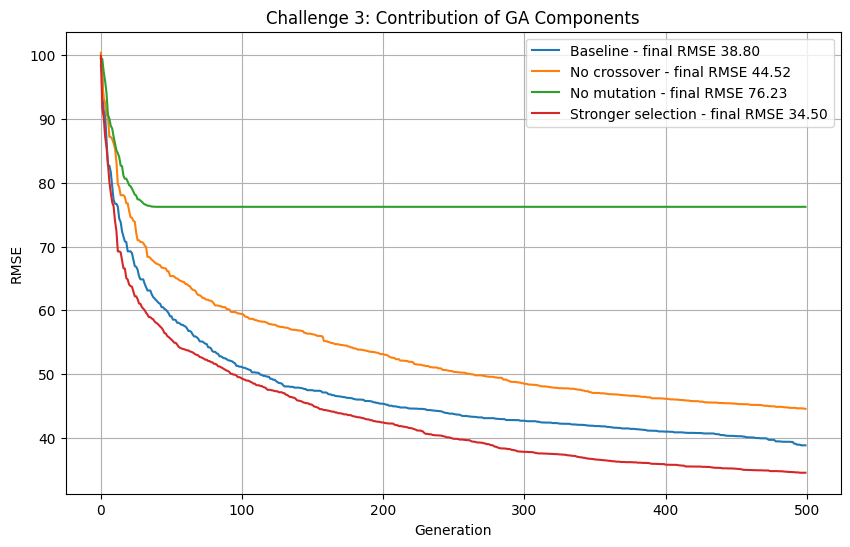

In [14]:
# Keep False by default so the notebook does not run long experiments accidentally.
# Set to True only when you want to run Challenge 3 experiments.
run_config_experiments = True

if run_config_experiments:
    # Load the same target image used in the main GA run.
    user = str(input("Select user (joao/goncalo): ").lower())
    if user == "joao":
        target_path = r"C:\Users\joaoa\Desktop\CIFO\data\girl_pearl_earing.png"
    elif user == "goncalo":
        target_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"
    target = cv2.imread(target_path)

    # Stop if the target image cannot be loaded.
    if target is None:
        raise FileNotFoundError(
            f"OpenCV could not find the image at: {target_path}"
        )

    # Run Challenge 3 with smaller values first because this can take a long time.
    challenge3_results = run_challenge3_experiments(
        target, pop_size=100, generations=500, pc=0.85, pm=0.03, elitism_size=3
    )

    # Plot the convergence curves for comparison.
    plot_challenge3_results(challenge3_results)

## Simulated Annealing

In [ ]:
from random import random, randint
import numpy as np
import cv2

class VermeerSolution(Solution):
    """A candidate painting made from 100 colored triangles."""

    def __init__(self, target_image, max_allowed_area, size_weight, repr=None):
        # Store the original image
        self.target_image = target_image

        # Project canvas size
        self.width = 300
        self.height = 400
        self.num_triangles = 100

        self.max_allowed_area = max_allowed_area
        self.size_weight = size_weight

        super().__init__(repr=repr)

    def random_initial_representation(self):
        random_repr = np.zeros((self.num_triangles, 9), dtype=int)
        for i in range(self.num_triangles):
            cx = randint(0, self.width)
            cy = randint(0, self.height)
            radius = 40
            x1 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y1 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x2 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y2 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x3 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y3 = np.clip(cy + randint(-radius, radius), 0, self.height)
            r, g, b = [randint(0, 255) for _ in range(3)]
            random_repr[i] = [x1, y1, x2, y2, x3, y3, r, g, b]
        return random_repr

    def render_canvas(self):
        canvas = np.zeros((self.height, self.width, 3), dtype=np.uint8)
        for gene in self.repr:
            pts = np.array([[gene[0], gene[1]], [gene[2], gene[3]], [gene[4], gene[5]]], np.int32)
            pts = pts.reshape((-1, 1, 2))
            color = (int(gene[6]), int(gene[7]), int(gene[8]))
            cv2.fillPoly(canvas, [pts], color)
        return canvas

    def fitness(self):
        """Calculates RMSE + Geometric Penalty (Shoelace Formula)"""
        generated_image = self.render_canvas()
        target_float = self.target_image.astype(np.float32)
        gen_float = generated_image.astype(np.float32)

        # 1. Erro Visual (RMSE)
        diff = target_float - gen_float
        sq_diff = np.square(diff)
        mse = np.mean(sq_diff)
        rmse = np.sqrt(mse)

        # 2. Penalização de Área (Shoelace Formula)
        x1, y1 = self.repr[:, 0], self.repr[:, 1]
        x2, y2 = self.repr[:, 2], self.repr[:, 3]
        x3, y3 = self.repr[:, 4], self.repr[:, 5]

        areas = 0.5 * np.abs(x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
        excess_area = np.maximum(0, areas - self.max_allowed_area)
        size_penalty = np.sum(excess_area) * self.size_weight

        return rmse + size_penalty

    def get_random_neighbor(self):
        """
        Generates a new solution optimized for Simulated Annealing.
        Uses Gaussian distributions and Heuristic color stealing.
        """
        neighbor = VermeerSolution(
            target_image=self.target_image, 
            max_allowed_area=self.max_allowed_area, 
            size_weight=self.size_weight,
            repr=self.repr.copy()
        )
        
        num_mutations = np.random.randint(1, 4) 
        
        for _ in range(num_mutations):
            i = np.random.randint(0, neighbor.num_triangles)
            mutation_type = random()
            
            if mutation_type < 0.50:
                nudge = np.random.normal(0, 4, 6).astype(int)
                neighbor.repr[i][0:6] += nudge
                neighbor.repr[i][0::2] = np.clip(neighbor.repr[i][0::2], 0, neighbor.width)
                neighbor.repr[i][1::2] = np.clip(neighbor.repr[i][1::2], 0, neighbor.height)
                
            elif mutation_type < 0.85:
                nudge = np.random.normal(0, 5, 3).astype(int)
                neighbor.repr[i][6:9] += nudge
                neighbor.repr[i][6:9] = np.clip(neighbor.repr[i][6:9], 0, 255)
                
            elif mutation_type < 0.95:
                swap_idx = np.random.randint(0, neighbor.num_triangles)
                neighbor.repr[[i, swap_idx]] = neighbor.repr[[swap_idx, i]]
                
            else:
                cx = np.random.randint(0, neighbor.width)
                cy = np.random.randint(0, neighbor.height)
                
                target_color = self.target_image[cy, cx]
                b, g, r = int(target_color[0]), int(target_color[1]), int(target_color[2])
                
                radius = 35
                x1 = np.clip(cx + np.random.randint(-radius, radius), 0, neighbor.width)
                y1 = np.clip(cy + np.random.randint(-radius, radius), 0, neighbor.height)
                x2 = np.clip(cx + np.random.randint(-radius, radius), 0, neighbor.width)
                y2 = np.clip(cy + np.random.randint(-radius, radius), 0, neighbor.height)
                x3 = np.clip(cx + np.random.randint(-radius, radius), 0, neighbor.width)
                y3 = np.clip(cy + np.random.randint(-radius, radius), 0, neighbor.height)
                
                neighbor.repr[i] = [x1, y1, x2, y2, x3, y3, r, g, b]
                
        return neighbor

In [22]:
def simulated_annealing(
    initial_solution: Solution,
    C: float,
    L: int,
    cooling_rate: float,
    max_iter: int = 10,
    verbose: bool = False,
):
    """
    Generic Simulated Annealing implementation kept from class material.

    NOTE: VermeerSolution would need get_random_neighbor() implemented for this to work on the painting problem.
    """
    # Start from the provided initial solution and calculate its fitness.
    current_solution = initial_solution
    current_fitness = current_solution.fitness()

    # Best global solution as SA can accept worse ones
    best_solution = initial_solution
    best_fitness = current_fitness

    C = C
    rmse_history = []  
    total_evals = 0

    for iteration in range(1, max_iter + 1):

        for _ in range(L):
            # Generate a neighbor with a slight mutation
            neighbor = current_solution.get_random_neighbor()
            neighbor_fitness = neighbor.fitness()
            total_evals += 1

            delta = neighbor_fitness - current_fitness   # less than 0, improvement

            if delta <= 0:
                # if the neighbor is better, accept it as current solution
                current_solution = neighbor
                current_fitness = neighbor_fitness
            else:
                # if the neighbor is worse, accept with probability of Boltzmann
                prob = np.exp(-delta / C) if C > 1e-10 else 0.0
                if random() < prob:
                    current_solution = neighbor
                    current_fitness = neighbor_fitness

            # Update global best
            if current_fitness < best_fitness:
                best_fitness = current_fitness
                # Save a copy of the best solution
                best_solution = VermeerSolution(
                    target_image=current_solution.target_image,
                    max_allowed_area=current_solution.max_allowed_area,
                    size_weight=current_solution.size_weight,
                    repr=current_solution.repr.copy(),
                )

            rmse_history.append(current_fitness)

        # Geometric cooling
        C *= cooling_rate

        if verbose and iteration % 500 == 0:
            print(
                f"  Iter {iteration:5d}/{max_iter} | "
                f"C={C:.4f} | "
                f"RMSE atual={current_fitness:.2f} | "
                f"Best={best_fitness:.2f}"
            )

    return best_solution, rmse_history


Starting Simulated Annealing with 800000 evaluations...
Initial Temperature: 20.0 | Cooling Rate: 0.999
  Iter   500/8000 | C=12.1276 | RMSE atual=95.62 | Best=87.66
  Iter  1000/8000 | C=7.3539 | RMSE atual=92.99 | Best=86.74
  Iter  1500/8000 | C=4.4593 | RMSE atual=92.35 | Best=85.55
  Iter  2000/8000 | C=2.7040 | RMSE atual=90.00 | Best=85.34
  Iter  2500/8000 | C=1.6396 | RMSE atual=89.44 | Best=85.34
  Iter  3000/8000 | C=0.9942 | RMSE atual=74.30 | Best=73.75
  Iter  3500/8000 | C=0.6029 | RMSE atual=66.10 | Best=64.63
  Iter  4000/8000 | C=0.3656 | RMSE atual=57.42 | Best=55.57
  Iter  4500/8000 | C=0.2217 | RMSE atual=53.69 | Best=50.40
  Iter  5000/8000 | C=0.1344 | RMSE atual=48.50 | Best=44.85
  Iter  5500/8000 | C=0.0815 | RMSE atual=42.33 | Best=41.10
  Iter  6000/8000 | C=0.0494 | RMSE atual=32.83 | Best=32.62
  Iter  6500/8000 | C=0.0300 | RMSE atual=29.28 | Best=29.20
  Iter  7000/8000 | C=0.0182 | RMSE atual=26.36 | Best=26.00
  Iter  7500/8000 | C=0.0110 | RMSE atual

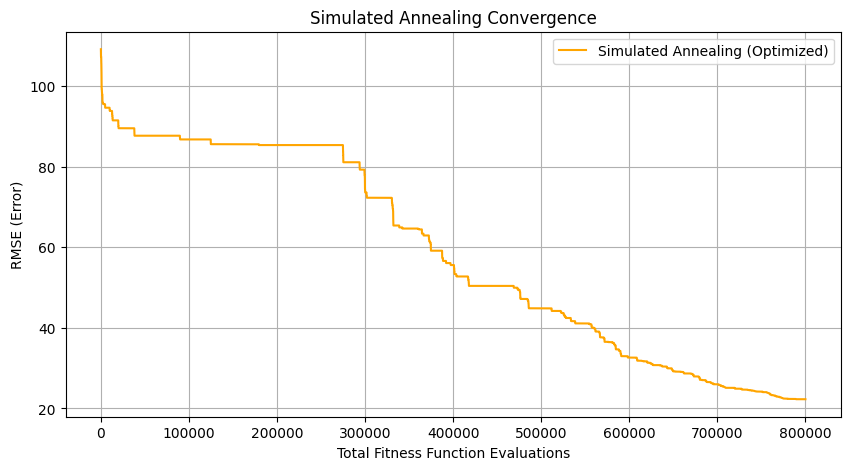

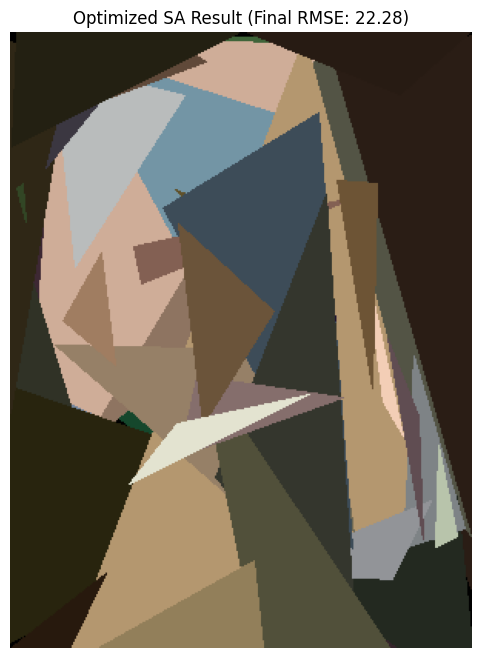

In [25]:
import matplotlib.pyplot as plt
import cv2

# 1. Define the target image
target = original_image 

# 2. Optimized Parameters (L * max_iter = 1,600,000 evaluations)
L_param = 100         
max_iter_param = 8000 
C_inicial = 20.0      
cooling_rate_param = 0.9990 

# 3. Initialize the first solution
sa_initial = VermeerSolution(target_image=target, max_allowed_area=1600, size_weight=0.000001)

print(f"Starting Simulated Annealing with {L_param * max_iter_param} evaluations...")
print(f"Initial Temperature: {C_inicial} | Cooling Rate: {cooling_rate_param}")

# 4. Execute the Algorithm (verbose=False is mandatory to prevent freezing!)
best_sa_sol, sa_history = simulated_annealing(
    initial_solution=sa_initial,
    C=C_inicial, 
    L=L_param, 
    cooling_rate=cooling_rate_param, 
    max_iter=max_iter_param, 
    verbose=True
)

# 5. Process data for the convergence plot (track the best-so-far)
best_so_far_sa = []
current_best = sa_history[0]

for score in sa_history:
    if score < current_best:
        current_best = score
    best_so_far_sa.append(current_best)

print(f"Final SA RMSE: {best_sa_sol.fitness():.2f}")

# 6. Display the Convergence Plot
plt.figure(figsize=(10, 5))
plt.plot(best_so_far_sa, label="Simulated Annealing (Optimized)", color="orange")
plt.xlabel("Total Fitness Function Evaluations")
plt.ylabel("RMSE (Error)")
plt.title("Simulated Annealing Convergence")
plt.legend()
plt.grid(True)
plt.show()

# 7. Display the Final Generated Image
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(best_sa_sol.render_canvas(), cv2.COLOR_BGR2RGB))
plt.title(f"Optimized SA Result (Final RMSE: {best_sa_sol.fitness():.2f})")
plt.axis("off")
plt.show()

In [21]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DO LOTE ---
EXP_NAME = "Control_Baseline"
NOTES = "Standard benchmark run (Tournament + Uniform + Swap). Fitness Sharing turned off for natural variation testing."

# Hiperparâmetros do Algoritmo
SELECTION = "tournament"
CROSSOVER = "uniform"
MUTATION = "swap"
NUM_RUNS = 30

POP_SIZE = 10
GENERATIONS = 500
PC = 0.85
PM = 0.03
ELITISM_SIZE = 3
TOURNAMENT_SIZE = 4
VARIANCE_THRESHOLD = 550
USE_FITNESS_SHARING = False

print(f"\n[{time.strftime('%H:%M:%S')}] Starting batch: {EXP_NAME} ({NUM_RUNS} Runs)")

variant_dir = os.path.join("data", "results", EXP_NAME)
if not os.path.exists(variant_dir):
    os.makedirs(variant_dir)

all_runs_history = []
final_rmses = []

for run in range(1, NUM_RUNS + 1):
    print(f"Run {run}/{NUM_RUNS}...")
    
    run_dir = os.path.join(variant_dir, f"Run_{run}")
    if not os.path.exists(run_dir):
        os.makedirs(run_dir)
        
    ga = VermeerGA3(
        target_image=original_image,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        pc=PC,
        pm=PM,
        elitism_size=ELITISM_SIZE,
        selection_method=SELECTION,
        crossover_method=CROSSOVER,
        mutation_method=MUTATION,
        use_fitness_sharing=USE_FITNESS_SHARING,
        # Se o teu __init__ aceitar estes parâmetros, passa-os. Caso contrário, podes omitir.
        # tournament_size=TOURNAMENT_SIZE, 
        # variance_threshold=VARIANCE_THRESHOLD
    )
    
    best_sol, fitness_history, variance_history = ga.run()
    
    # --- NOVO: Preparar o dicionário de histórico pedido ---
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen] if gen < len(variance_history) else variance_history[-1]
        }
    
    # --- NOVO: Gravação detalhada de Hiperparâmetros ---
    hyperparameter_path = os.path.join(run_dir, "hyperparameters.txt")
    with open(hyperparameter_path, "w") as file:
        file.write(f"GA3 Hyperparameters for {EXP_NAME} | Run Number: {run}\n\n")
        
        if NOTES:
            file.write(f"Notes for this run: {NOTES}\n\n")
            
        file.write(f"--- VARIANT SETUP ---\n")
        file.write(f"Selection Method: {SELECTION}\n")
        file.write(f"Crossover Method: {CROSSOVER}\n")
        file.write(f"Mutation Method: {MUTATION}\n\n")
        
        file.write(f"--- BASE PARAMETERS ---\n")
        file.write(f"Population Size: {POP_SIZE}\n")
        file.write(f"Generations: {GENERATIONS}\n")
        file.write(f"Crossover Probability (pc): {PC}\n")
        file.write(f"Mutation Probability (pm): {PM}\n")
        file.write(f"Elitism Size: {ELITISM_SIZE}\n")
        file.write(f"Tournament Size: {TOURNAMENT_SIZE}\n")
        file.write(f"Fitness Sharing: {USE_FITNESS_SHARING}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {VARIANCE_THRESHOLD}\n\n")
        
        file.write(f"--- GENERATION HISTORY ---\n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
                
        file.write(f"\n--- FINAL RESULTS ---\n")
        file.write(f"Final RMSE Score: {best_sol.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")

    # Guardar a imagem e o gráfico
    cv2.imwrite(os.path.join(run_dir, "final_result.png"), best_sol.render_canvas())

    plt.figure(figsize=(8, 4))
    plt.plot(fitness_history, color='black', linewidth=1.5)
    plt.title(f"Convergence - {EXP_NAME} Run {run} (Final: {fitness_history[-1]:.2f})")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.savefig(os.path.join(run_dir, "convergence_plot.png"), bbox_inches='tight')
    plt.close()
    
    all_runs_history.append(fitness_history)
    final_rmses.append(fitness_history[-1])

print(f"\n[{time.strftime('%H:%M:%S')}] Batch {EXP_NAME} finished! Best final RMSE: {np.mean(final_rmses):.2f}")

# --- GUARDAR DADOS GLOBAIS EM CSV ---
history_matrix = np.array(all_runs_history)

raw_df = pd.DataFrame(history_matrix)
raw_df.index = [f"Run_{i+1}" for i in range(NUM_RUNS)]
raw_df.columns = [f"Gen_{i}" for i in range(GENERATIONS + 1)]
raw_df.to_csv(os.path.join(variant_dir, "raw_fitness_data.csv"))

stats_df = pd.DataFrame({
    "Generation": np.arange(GENERATIONS + 1),
    "Mean_RMSE": np.mean(history_matrix, axis=0),
    "Std_Dev": np.std(history_matrix, axis=0),
    "Best_RMSE": np.min(history_matrix, axis=0)
})
stats_df.to_csv(os.path.join(variant_dir, "statistical_summary.csv"), index=False)


[21:41:03] Starting batch: Control_Baseline (30 Runs)
Run 1/30...
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 105.33 | Variance: 8028.32

 Variance dropped to 270.71 Fitness Sharing Activated at Gen: 13


KeyboardInterrupt: 

In [20]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DO LOTE ---
EXP_NAME = "Selection_Variant_Ranking"
NOTES = "Selection Isolation: Ranking test to assess whether it prevents premature convergence. Uniform Crossover and Swap Mutation."

# Hiperparâmetros do Algoritmo
SELECTION = "ranking" # <-- ALTERAÇÃO CRÍTICA
CROSSOVER = "uniform"
MUTATION = "swap"
NUM_RUNS = 30

POP_SIZE = 100
GENERATIONS = 500
PC = 0.85
PM = 0.03
ELITISM_SIZE = 3
TOURNAMENT_SIZE = 4
VARIANCE_THRESHOLD = 550
USE_FITNESS_SHARING = False

print(f"\n[{time.strftime('%H:%M:%S')}] Starting batch: {EXP_NAME} ({NUM_RUNS} Runs)")

variant_dir = os.path.join("data", "results", EXP_NAME)
if not os.path.exists(variant_dir):
    os.makedirs(variant_dir)

all_runs_history = []
final_rmses = []

for run in range(1, NUM_RUNS + 1):
    print(f"Run {run}/{NUM_RUNS}...")
    
    run_dir = os.path.join(variant_dir, f"Run_{run}")
    if not os.path.exists(run_dir):
        os.makedirs(run_dir)
        
    ga = VermeerGA3(
        target_image=original_image,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        pc=PC,
        pm=PM,
        elitism_size=ELITISM_SIZE,
        selection_method=SELECTION,
        crossover_method=CROSSOVER,
        mutation_method=MUTATION,
        use_fitness_sharing=USE_FITNESS_SHARING
    )
    
    best_sol, fitness_history, variance_history = ga.run()
    
    # Preparar o dicionário de histórico
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen] if gen < len(variance_history) else variance_history[-1]
        }
    
    # Gravação detalhada de Hiperparâmetros
    hyperparameter_path = os.path.join(run_dir, "hyperparameters.txt")
    with open(hyperparameter_path, "w") as file:
        file.write(f"GA3 Hyperparameters for {EXP_NAME} | Run Number: {run}\n\n")
        
        if NOTES:
            file.write(f"Notes for this run: {NOTES}\n\n")
            
        file.write(f"--- VARIANT SETUP ---\n")
        file.write(f"Selection Method: {SELECTION}\n")
        file.write(f"Crossover Method: {CROSSOVER}\n")
        file.write(f"Mutation Method: {MUTATION}\n\n")
        
        file.write(f"--- BASE PARAMETERS ---\n")
        file.write(f"Population Size: {POP_SIZE}\n")
        file.write(f"Generations: {GENERATIONS}\n")
        file.write(f"Crossover Probability (pc): {PC}\n")
        file.write(f"Mutation Probability (pm): {PM}\n")
        file.write(f"Elitism Size: {ELITISM_SIZE}\n")
        file.write(f"Tournament Size: {TOURNAMENT_SIZE}\n")
        file.write(f"Fitness Sharing: {USE_FITNESS_SHARING}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {VARIANCE_THRESHOLD}\n\n")
        
        file.write(f"--- GENERATION HISTORY ---\n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
                
        file.write(f"\n--- FINAL RESULTS ---\n")
        file.write(f"Final RMSE Score: {best_sol.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")

    # Guardar a imagem e o gráfico
    cv2.imwrite(os.path.join(run_dir, "final_result.png"), best_sol.render_canvas())

    plt.figure(figsize=(8, 4))
    plt.plot(fitness_history, color='blue', linewidth=1.5) # Cor Azul para o Ranking
    plt.title(f"Convergence - {EXP_NAME} Run {run} (Final: {fitness_history[-1]:.2f})")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.savefig(os.path.join(run_dir, "convergence_plot.png"), bbox_inches='tight')
    plt.close()
    
    all_runs_history.append(fitness_history)
    final_rmses.append(fitness_history[-1])

print(f"\n[{time.strftime('%H:%M:%S')}] Batch {EXP_NAME} finished! Best final RMSE: {np.mean(final_rmses):.2f}")

# --- GUARDAR DADOS GLOBAIS EM CSV ---
history_matrix = np.array(all_runs_history)

raw_df = pd.DataFrame(history_matrix)
raw_df.index = [f"Run_{i+1}" for i in range(NUM_RUNS)]
raw_df.columns = [f"Gen_{i}" for i in range(GENERATIONS + 1)]
raw_df.to_csv(os.path.join(variant_dir, "raw_fitness_data.csv"))

stats_df = pd.DataFrame({
    "Generation": np.arange(GENERATIONS + 1),
    "Mean_RMSE": np.mean(history_matrix, axis=0),
    "Std_Dev": np.std(history_matrix, axis=0),
    "Best_RMSE": np.min(history_matrix, axis=0)
})
stats_df.to_csv(os.path.join(variant_dir, "statistical_summary.csv"), index=False)



[21:40:58] Starting batch: Selection_Variant_Ranking (30 Runs)
Run 1/30...
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 99.39 | Variance: 8971.97


KeyboardInterrupt: 

In [19]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DO LOTE ---
EXP_NAME = "Crossover_Variant_TwoPoint"
NOTES = "Crossover Insulation: Testing with Two-Point (OX) to evaluate layer construction. Tournament Selection and Swap Mutation."

# Hiperparâmetros do Algoritmo
SELECTION = "tournament" 
CROSSOVER = "two_point" # <-- ALTERAÇÃO CRÍTICA
MUTATION = "swap"
NUM_RUNS = 30

POP_SIZE = 100
GENERATIONS = 500
PC = 0.85
PM = 0.03
ELITISM_SIZE = 3
TOURNAMENT_SIZE = 4
VARIANCE_THRESHOLD = 550
USE_FITNESS_SHARING = False

print(f"\n[{time.strftime('%H:%M:%S')}] Starting batch: {EXP_NAME} ({NUM_RUNS} Runs)")

variant_dir = os.path.join("data", "results", EXP_NAME)
if not os.path.exists(variant_dir):
    os.makedirs(variant_dir)

all_runs_history = []
final_rmses = []

for run in range(1, NUM_RUNS + 1):
    print(f"Run {run}/{NUM_RUNS}...")
    
    run_dir = os.path.join(variant_dir, f"Run_{run}")
    if not os.path.exists(run_dir):
        os.makedirs(run_dir)
        
    ga = VermeerGA3(
        target_image=original_image,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        pc=PC,
        pm=PM,
        elitism_size=ELITISM_SIZE,
        selection_method=SELECTION,
        crossover_method=CROSSOVER,
        mutation_method=MUTATION,
        use_fitness_sharing=USE_FITNESS_SHARING
    )
    
    best_sol, fitness_history, variance_history = ga.run()
    
    # Preparar o dicionário de histórico
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen] if gen < len(variance_history) else variance_history[-1]
        }
    
    # Gravação detalhada de Hiperparâmetros
    hyperparameter_path = os.path.join(run_dir, "hyperparameters.txt")
    with open(hyperparameter_path, "w") as file:
        file.write(f"GA3 Hyperparameters for {EXP_NAME} | Run Number: {run}\n\n")
        
        if NOTES:
            file.write(f"Notes for this run: {NOTES}\n\n")
            
        file.write(f"--- VARIANT SETUP ---\n")
        file.write(f"Selection Method: {SELECTION}\n")
        file.write(f"Crossover Method: {CROSSOVER}\n")
        file.write(f"Mutation Method: {MUTATION}\n\n")
        
        file.write(f"--- BASE PARAMETERS ---\n")
        file.write(f"Population Size: {POP_SIZE}\n")
        file.write(f"Generations: {GENERATIONS}\n")
        file.write(f"Crossover Probability (pc): {PC}\n")
        file.write(f"Mutation Probability (pm): {PM}\n")
        file.write(f"Elitism Size: {ELITISM_SIZE}\n")
        file.write(f"Tournament Size: {TOURNAMENT_SIZE}\n")
        file.write(f"Fitness Sharing: {USE_FITNESS_SHARING}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {VARIANCE_THRESHOLD}\n\n")
        
        file.write(f"--- GENERATION HISTORY ---\n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
                
        file.write(f"\n--- FINAL RESULTS ---\n")
        file.write(f"Final RMSE Score: {best_sol.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")

    # Guardar a imagem e o gráfico
    cv2.imwrite(os.path.join(run_dir, "final_result.png"), best_sol.render_canvas())

    plt.figure(figsize=(8, 4))
    plt.plot(fitness_history, color='green', linewidth=1.5) # Cor Verde para o Two-Point
    plt.title(f"Convergence - {EXP_NAME} Run {run} (Final: {fitness_history[-1]:.2f})")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.savefig(os.path.join(run_dir, "convergence_plot.png"), bbox_inches='tight')
    plt.close()
    
    all_runs_history.append(fitness_history)
    final_rmses.append(fitness_history[-1])

print(f"\n[{time.strftime('%H:%M:%S')}] Batch {EXP_NAME} finished! Best final RMSE: {np.mean(final_rmses):.2f}")

# --- GUARDAR DADOS GLOBAIS EM CSV ---
history_matrix = np.array(all_runs_history)

raw_df = pd.DataFrame(history_matrix)
raw_df.index = [f"Run_{i+1}" for i in range(NUM_RUNS)]
raw_df.columns = [f"Gen_{i}" for i in range(GENERATIONS + 1)]
raw_df.to_csv(os.path.join(variant_dir, "raw_fitness_data.csv"))

stats_df = pd.DataFrame({
    "Generation": np.arange(GENERATIONS + 1),
    "Mean_RMSE": np.mean(history_matrix, axis=0),
    "Std_Dev": np.std(history_matrix, axis=0),
    "Best_RMSE": np.min(history_matrix, axis=0)
})
stats_df.to_csv(os.path.join(variant_dir, "statistical_summary.csv"), index=False)



[21:40:51] Starting batch: Crossover_Variant_TwoPoint (30 Runs)
Run 1/30...
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 98.50 | Variance: 8838.24


KeyboardInterrupt: 

In [18]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DO LOTE ---
EXP_NAME = "Mutation_Variant_Scramble"
NOTES = "Mutation Isolation: Scramble test to evaluate drastic space exploration jumps. Tournament Selection and Crossover Uniform."

# Hiperparâmetros do Algoritmo
SELECTION = "tournament"
CROSSOVER = "uniform"
MUTATION = "scramble" # <-- ALTERAÇÃO CRÍTICA
NUM_RUNS = 30

POP_SIZE = 100
GENERATIONS = 500
PC = 0.85
PM = 0.03
ELITISM_SIZE = 3
TOURNAMENT_SIZE = 4
VARIANCE_THRESHOLD = 550
USE_FITNESS_SHARING = False

print(f"\n[{time.strftime('%H:%M:%S')}] Starting batch: {EXP_NAME} ({NUM_RUNS} Runs)")

variant_dir = os.path.join("data", "results", EXP_NAME)
if not os.path.exists(variant_dir):
    os.makedirs(variant_dir)

all_runs_history = []
final_rmses = []

for run in range(1, NUM_RUNS + 1):
    print(f"Run {run}/{NUM_RUNS}...")
    
    run_dir = os.path.join(variant_dir, f"Run_{run}")
    if not os.path.exists(run_dir):
        os.makedirs(run_dir)
        
    ga = VermeerGA3(
        target_image=original_image,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        pc=PC,
        pm=PM,
        elitism_size=ELITISM_SIZE,
        selection_method=SELECTION,
        crossover_method=CROSSOVER,
        mutation_method=MUTATION,
        use_fitness_sharing=USE_FITNESS_SHARING
    )
    
    best_sol, fitness_history, variance_history = ga.run()
    
    # Preparar o dicionário de histórico
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen] if gen < len(variance_history) else variance_history[-1]
        }
    
    # Gravação detalhada de Hiperparâmetros
    hyperparameter_path = os.path.join(run_dir, "hyperparameters.txt")
    with open(hyperparameter_path, "w") as file:
        file.write(f"GA3 Hyperparameters for {EXP_NAME} | Run Number: {run}\n\n")
        
        if NOTES:
            file.write(f"Notes for this run: {NOTES}\n\n")
            
        file.write(f"--- VARIANT SETUP ---\n")
        file.write(f"Selection Method: {SELECTION}\n")
        file.write(f"Crossover Method: {CROSSOVER}\n")
        file.write(f"Mutation Method: {MUTATION}\n\n")
        
        file.write(f"--- BASE PARAMETERS ---\n")
        file.write(f"Population Size: {POP_SIZE}\n")
        file.write(f"Generations: {GENERATIONS}\n")
        file.write(f"Crossover Probability (pc): {PC}\n")
        file.write(f"Mutation Probability (pm): {PM}\n")
        file.write(f"Elitism Size: {ELITISM_SIZE}\n")
        file.write(f"Tournament Size: {TOURNAMENT_SIZE}\n")
        file.write(f"Fitness Sharing: {USE_FITNESS_SHARING}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {VARIANCE_THRESHOLD}\n\n")
        
        file.write(f"--- GENERATION HISTORY ---\n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
                
        file.write(f"\n--- FINAL RESULTS ---\n")
        file.write(f"Final RMSE Score: {best_sol.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")

    # Guardar a imagem e o gráfico
    cv2.imwrite(os.path.join(run_dir, "final_result.png"), best_sol.render_canvas())

    plt.figure(figsize=(8, 4))
    plt.plot(fitness_history, color='red', linewidth=1.5) # Cor Vermelha para o Scramble
    plt.title(f"Convergence - {EXP_NAME} Run {run} (Final: {fitness_history[-1]:.2f})")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.savefig(os.path.join(run_dir, "convergence_plot.png"), bbox_inches='tight')
    plt.close()
    
    all_runs_history.append(fitness_history)
    final_rmses.append(fitness_history[-1])

print(f"\n[{time.strftime('%H:%M:%S')}] Batch {EXP_NAME} finished! Best final RMSE: {np.mean(final_rmses):.2f}")

# --- GUARDAR DADOS GLOBAIS EM CSV ---
history_matrix = np.array(all_runs_history)

raw_df = pd.DataFrame(history_matrix)
raw_df.index = [f"Run_{i+1}" for i in range(NUM_RUNS)]
raw_df.columns = [f"Gen_{i}" for i in range(GENERATIONS + 1)]
raw_df.to_csv(os.path.join(variant_dir, "raw_fitness_data.csv"))

stats_df = pd.DataFrame({
    "Generation": np.arange(GENERATIONS + 1),
    "Mean_RMSE": np.mean(history_matrix, axis=0),
    "Std_Dev": np.std(history_matrix, axis=0),
    "Best_RMSE": np.min(history_matrix, axis=0)
})
stats_df.to_csv(os.path.join(variant_dir, "statistical_summary.csv"), index=False)



[21:40:41] Starting batch: Mutation_Variant_Scramble (30 Runs)
Run 1/30...
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 100.34 | Variance: 8802.22


KeyboardInterrupt: 